<a href="https://colab.research.google.com/github/EdisonZyberaj/CV_Exercise1/blob/main/Exercise3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# Required libraries for image classification tasks

import numpy as np
import matplotlib.pyplot as plt

from skimage.io import imread
from skimage.color import rgb2gray, label2rgb
from skimage import exposure

from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops

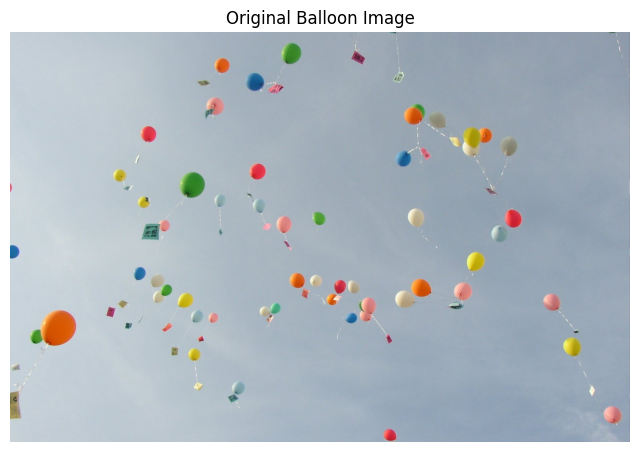

In [15]:
from matplotlib.image import imread
import matplotlib.pyplot as plt

# Load the balloon image
balloon_img = imread('baloons.jpg')

# Display image
plt.figure(figsize=(8,6))
plt.imshow(balloon_img)
plt.title("Original Balloon Image")
plt.axis("off")
plt.show()

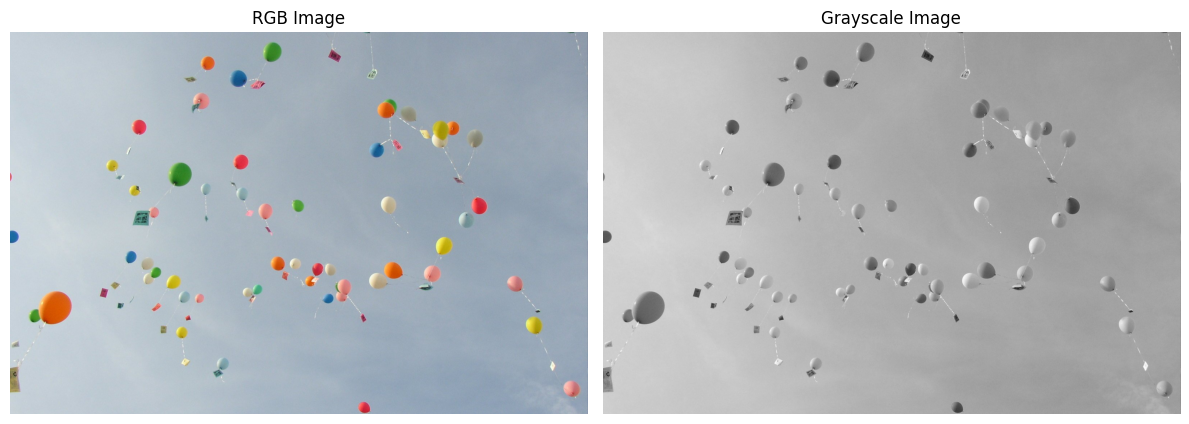

In [16]:
# Convert image to grayscale

gray_img = rgb2gray(balloon_img)

# Compare original and grayscale images

fig, ax = plt.subplots(1, 2, figsize=(12,6))

ax[0].imshow(balloon_img)
ax[0].set_title("RGB Image")
ax[0].axis("off")

ax[1].imshow(gray_img, cmap='gray')
ax[1].set_title("Grayscale Image")
ax[1].axis("off")

plt.tight_layout()
plt.show()

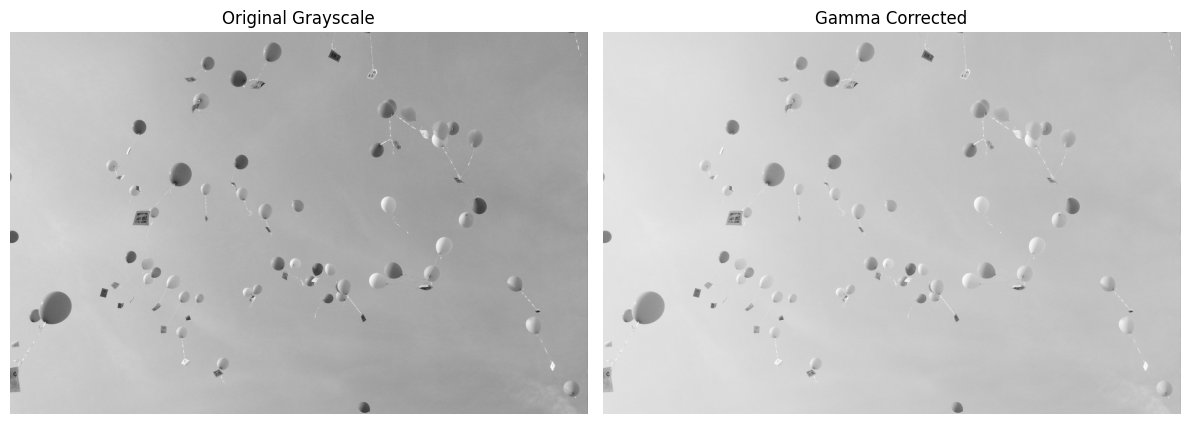

In [17]:
# Improve image brightness using gamma correction

gamma_img = exposure.adjust_gamma(gray_img, gamma=0.5)

# Display results

fig, ax = plt.subplots(1, 2, figsize=(12,6))

ax[0].imshow(gray_img, cmap='gray')
ax[0].set_title("Original Grayscale")
ax[0].axis("off")

ax[1].imshow(gamma_img, cmap='gray')
ax[1].set_title("Gamma Corrected")
ax[1].axis("off")

plt.tight_layout()
plt.show()

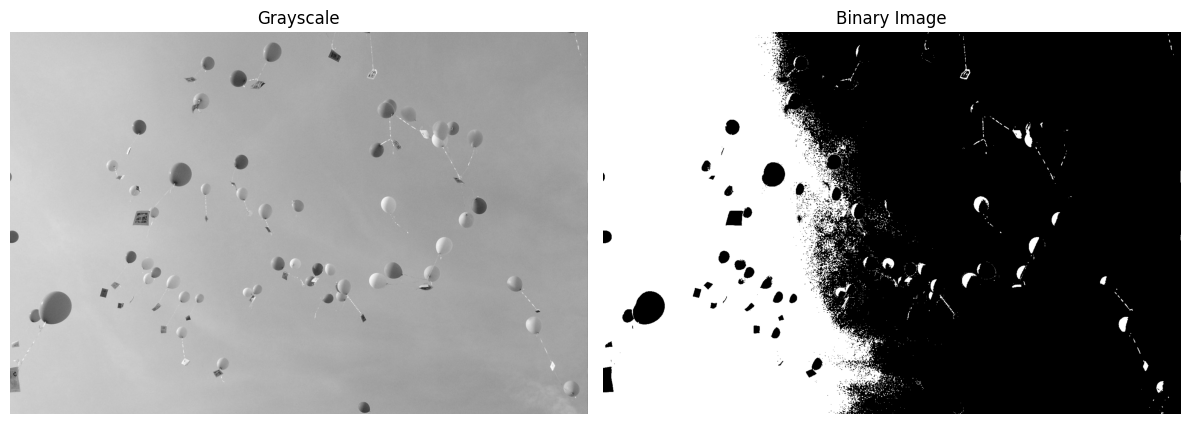

In [18]:
# Automatic thresholding using Otsu method

otsu_value = threshold_otsu(gray_img)

binary_img = gray_img > otsu_value

# Show binary result

fig, ax = plt.subplots(1, 2, figsize=(12,6))

ax[0].imshow(gray_img, cmap='gray')
ax[0].set_title("Grayscale")
ax[0].axis("off")

ax[1].imshow(binary_img, cmap='gray')
ax[1].set_title("Binary Image")
ax[1].axis("off")

plt.tight_layout()
plt.show()

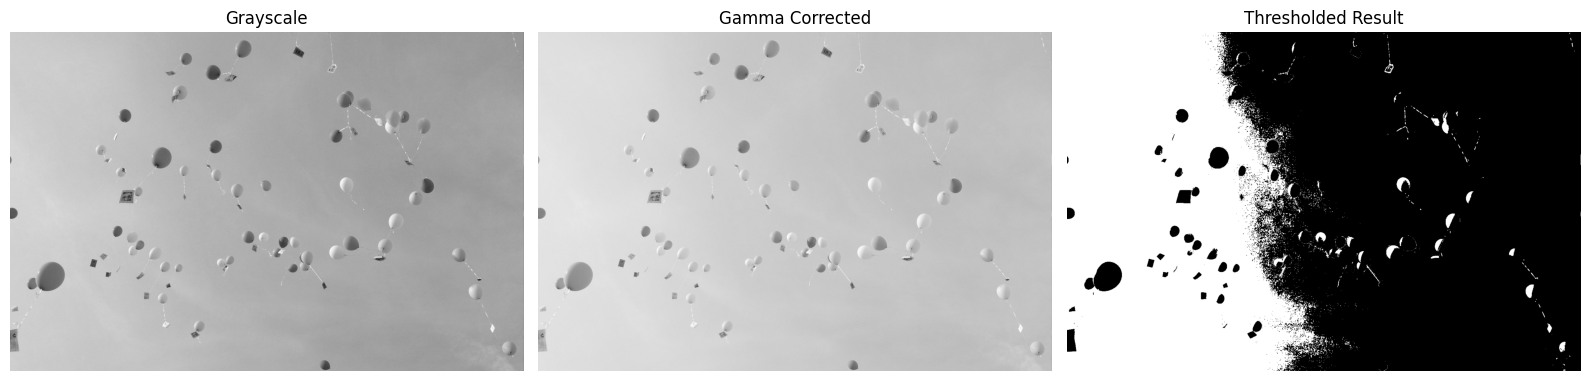

In [19]:
# Otsu thresholding after gamma correction

gamma_threshold = threshold_otsu(gamma_img)

binary_gamma = gamma_img > gamma_threshold

# Display all images

fig, ax = plt.subplots(1, 3, figsize=(16,6))

ax[0].imshow(gray_img, cmap='gray')
ax[0].set_title("Grayscale")
ax[0].axis("off")

ax[1].imshow(gamma_img, cmap='gray')
ax[1].set_title("Gamma Corrected")
ax[1].axis("off")

ax[2].imshow(binary_gamma, cmap='gray')
ax[2].set_title("Thresholded Result")
ax[2].axis("off")

plt.tight_layout()
plt.show()

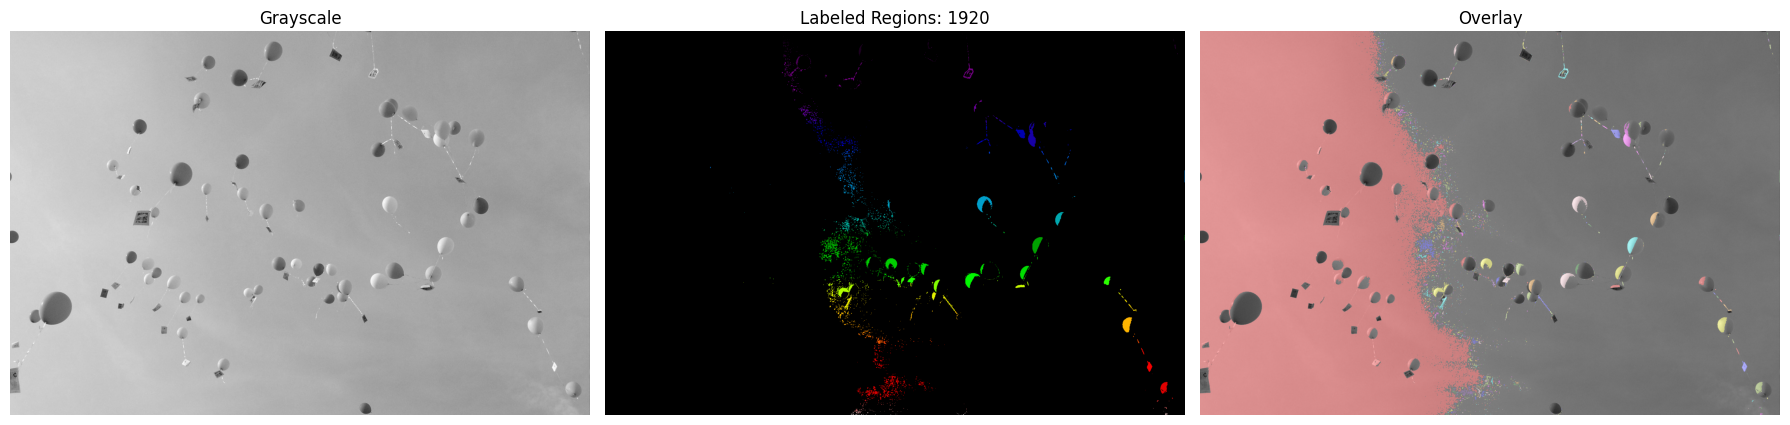

In [20]:
# Label connected regions

labeled_img, total_regions = label(binary_gamma, return_num=True)

overlay = label2rgb(labeled_img, image=gray_img)

# Visualization

fig, ax = plt.subplots(1, 3, figsize=(18,6))

ax[0].imshow(gray_img, cmap='gray')
ax[0].set_title("Grayscale")
ax[0].axis("off")

ax[1].imshow(labeled_img, cmap='nipy_spectral')
ax[1].set_title(f"Labeled Regions: {total_regions}")
ax[1].axis("off")

ax[2].imshow(overlay)
ax[2].set_title("Overlay")
ax[2].axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Extract region properties

regions = regionprops(labeled_img)

print("Detected Regions:\n")

for index, region in enumerate(regions):

    print(f"Region {index+1}")
    print(f"Area: {region.area}")
    print(f"Eccentricity: {region.eccentricity:.3f}")
    print("----------------------------")

Streaming output truncated to the last 5000 lines.
Region 671
Area: 10.0
Eccentricity: 0.963
----------------------------
Region 672
Area: 1.0
Eccentricity: 0.000
----------------------------
Region 673
Area: 2.0
Eccentricity: 1.000
----------------------------
Region 674
Area: 1.0
Eccentricity: 0.000
----------------------------
Region 675
Area: 2.0
Eccentricity: 1.000
----------------------------
Region 676
Area: 2.0
Eccentricity: 1.000
----------------------------
Region 677
Area: 2.0
Eccentricity: 1.000
----------------------------
Region 678
Area: 4.0
Eccentricity: 1.000
----------------------------
Region 679
Area: 3.0
Eccentricity: 1.000
----------------------------
Region 680
Area: 1.0
Eccentricity: 0.000
----------------------------
Region 681
Area: 3.0
Eccentricity: 1.000
----------------------------
Region 682
Area: 8.0
Eccentricity: 0.612
----------------------------
Region 683
Area: 5.0
Eccentricity: 0.816
----------------------------
Region 684
Area: 4.0
Eccentricity: 0.7

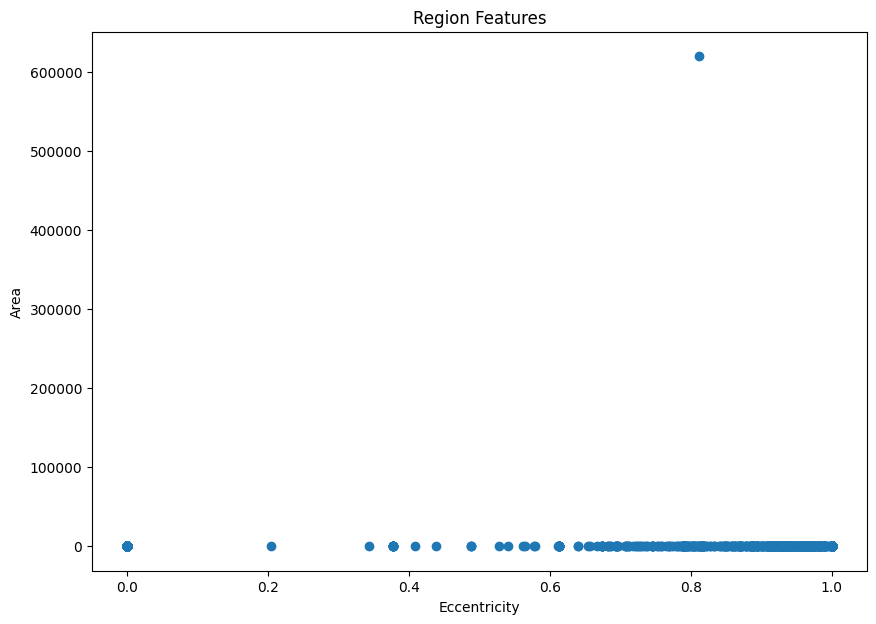

In [22]:
# Create feature matrix

feature_data = np.zeros((total_regions, 2))

for i, region in enumerate(regions):

    feature_data[i, 0] = region.area
    feature_data[i, 1] = region.eccentricity

# Scatter plot

plt.figure(figsize=(10,7))

plt.scatter(
    feature_data[:,1],
    feature_data[:,0],
    marker='o'
)

plt.xlabel("Eccentricity")
plt.ylabel("Area")
plt.title("Region Features")

plt.show()

In [23]:
# Balloon filtering conditions

balloon_index = np.where(
    (feature_data[:,0] > 500) &
    (feature_data[:,1] < 0.8)
)

print("Detected balloons:", len(balloon_index[0]))

Detected balloons: 3


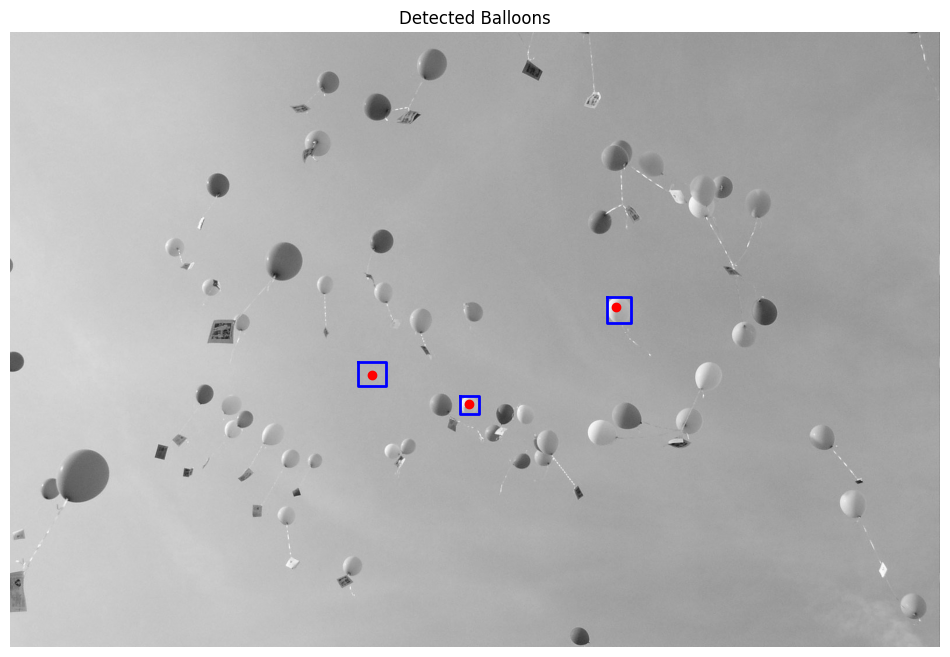

In [24]:
# Plot detected balloons

fig, ax = plt.subplots(figsize=(12,8))

ax.imshow(gray_img, cmap='gray')

for idx in np.squeeze(balloon_index):

    region = regions[idx]

    y_center, x_center = region.centroid

    ax.plot(x_center, y_center, '.r', markersize=12)

    min_row, min_col, max_row, max_col = region.bbox

    rect_x = [min_col, max_col, max_col, min_col, min_col]
    rect_y = [min_row, min_row, max_row, max_row, min_row]

    ax.plot(rect_x, rect_y, '-b', linewidth=2)

ax.set_title("Detected Balloons")
ax.axis("off")

plt.show()